# Weather Precipitation Strategy — 2025 Backtest

Full pipeline: load Corn Belt aggregate weather features + corn futures,
generate drought/flood signals, run dollar P&L backtest with 1% risk sizing.

- **Period**: 2025-01-01 to present
- **Capital**: $100,000,000
- **Risk per trade**: 1% of current equity
- **Strategy**: Long-only on extreme precipitation anomalies (drought < -1σ, flood > +1.5σ)

In [1]:
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from features import store
from eda.signal_gen import load_futures
from strategies.weather_precipitation import generate_signal, DROUGHT_THRESHOLD, FLOOD_THRESHOLD
from strategies.backtest import run_backtest

logging.basicConfig(
    level=logging.INFO, stream=sys.stdout,
    format="%(asctime)s %(name)s %(levelname)s %(message)s",
)

VISUALS_DIR = Path("visuals")
VISUALS_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Load data
weather = store.read_features("weather", "corn_belt")
futures = load_futures()

# Join on trading days
weather = weather.set_index(pd.to_datetime(weather["date"]))
df = futures.join(weather[["precip_anomaly_30d"]], how="inner")

# Filter to 2025+
df = df.loc["2025-01-01":]
print(f"Backtest period: {df.index[0].date()} to {df.index[-1].date()} ({len(df)} trading days)")

2026-03-12 21:44:44,557 eda.signal_gen INFO Loaded futures: 4068 rows (2010-01-04 to 2026-03-11)
Backtest period: 2025-01-02 to 2026-03-10 (297 trading days)


## Signal Generation

The strategy goes long when the 30-day precipitation z-score indicates drought (< -1.0)
or flood (> +1.5). Both extremes threaten corn supply.

In [2]:
df = generate_signal(df)

print("Signal distribution:")
counts = df["signal"].value_counts().sort_index()
for val, count in counts.items():
    label = {0: "Flat", 1: "Long"}.get(val, str(val))
    print(f"  {label} ({val}): {count} days ({count/len(df)*100:.1f}%)")

Signal distribution:
  Flat (0): 282 days (94.9%)
  Long (1): 15 days (5.1%)


## Run Backtest

In [3]:
result_df, trade_log, stats = run_backtest(df, capital=100_000_000, risk_pct=0.01)

2026-03-12 21:44:46,538 strategies.backtest INFO Built trade log: 14 trades
2026-03-12 21:44:46,543 strategies.backtest INFO Backtest complete: total_pnl=$-36031, trades=14, win_rate=50.0%, sharpe=-0.62


## Performance Summary

In [4]:
summary_rows = [
    ("Period", f"{result_df.index[0].date()} to {result_df.index[-1].date()}"),
    ("Trading Days", f"{len(result_df)}"),
    ("", ""),
    ("Starting Equity", f"${stats['starting_equity']:,.0f}"),
    ("Ending Equity", f"${stats['ending_equity']:,.0f}"),
    ("Total P&L", f"${stats['total_pnl']:,.2f}"),
    ("Total Return", f"{stats['total_return_pct']:.4f}%"),
    ("", ""),
    ("Sharpe Ratio (annualized)", f"{stats['sharpe_ratio']:.2f}"),
    ("Max Drawdown", f"${stats['max_drawdown']:,.2f}"),
    ("Max Drawdown %", f"{stats['max_drawdown_pct']:.4f}%"),
    ("Profit Factor", f"{stats['profit_factor']:.2f}"),
    ("", ""),
    ("Num Trades", f"{stats['num_trades']}"),
    ("Win Rate", f"{stats['win_rate']:.1%}"),
    ("Avg Win", f"${stats['avg_win']:,.2f}"),
    ("Avg Loss", f"${stats['avg_loss']:,.2f}"),
    ("Best Trade", f"${stats['best_trade']:,.2f}"),
    ("Worst Trade", f"${stats['worst_trade']:,.2f}"),
    ("Avg Holding Days", f"{stats['avg_holding_days']:.1f}"),
    ("", ""),
    ("Longest Win Streak", f"{stats['longest_win_streak']}"),
    ("Longest Lose Streak", f"{stats['longest_lose_streak']}"),
]

summary_df = pd.DataFrame(summary_rows, columns=["Metric", "Value"])
summary_df.style.hide(axis="index").set_properties(**{"text-align": "left"})

Metric,Value
Period,2025-01-02 to 2026-03-10
Trading Days,297
,
Starting Equity,"$100,000,000"
Ending Equity,"$99,963,969"
Total P&L,"$-36,030.53"
Total Return,-0.0360%
,
Sharpe Ratio (annualized),-0.62
Max Drawdown,"$-83,221.96"


## Transaction Log

In [5]:
if len(trade_log) > 0:
    display_cols = ["entry_date", "exit_date", "direction", "entry_price",
                    "exit_price", "units", "pnl", "pnl_per_unit", "holding_days"]
    styled = (
        trade_log[display_cols]
        .style
        .format({
            "entry_price": "${:.2f}",
            "exit_price": "${:.2f}",
            "units": "{:,.1f}",
            "pnl": "${:,.2f}",
            "pnl_per_unit": "${:.2f}",
        })
        .map(
            lambda v: "color: green" if isinstance(v, (int, float)) and v > 0
            else ("color: red" if isinstance(v, (int, float)) and v < 0 else ""),
            subset=["pnl"]
        )
    )
    display(styled)
else:
    print("No trades generated.")

,entry_date,exit_date,direction,entry_price,exit_price,units,pnl,pnl_per_unit,holding_days
0,2025-02-14 00:00:00,2025-02-18 00:00:00,long,$496.25,$502.00,"2,015.1","$11,586.90",$5.75,4
1,2025-03-06 00:00:00,2025-03-07 00:00:00,long,$449.50,$455.25,"2,225.0","$12,793.47",$5.75,1
2,2025-03-21 00:00:00,2025-03-24 00:00:00,long,$464.25,$464.50,"2,154.5",$538.63,$0.25,3
3,2025-04-04 00:00:00,2025-04-07 00:00:00,long,$460.25,$464.50,"2,173.3","$9,236.41",$4.25,3
4,2025-04-22 00:00:00,2025-04-23 00:00:00,long,$475.75,$472.00,"2,102.7","$-7,884.98",$-3.75,1
5,2025-04-28 00:00:00,2025-04-29 00:00:00,long,$475.50,$460.50,"2,103.6","$-31,554.03",$-15.00,1
6,2025-05-02 00:00:00,2025-05-05 00:00:00,long,$461.25,$446.50,"2,167.9","$-31,976.63",$-14.75,3
7,2025-05-21 00:00:00,2025-05-23 00:00:00,long,$461.00,$459.50,"2,168.4","$-3,252.58",$-1.50,2
8,2025-06-05 00:00:00,2025-06-06 00:00:00,long,$439.50,$442.50,"2,274.4","$6,823.17",$3.00,1
9,2025-10-08 00:00:00,2025-10-09 00:00:00,long,$422.00,$418.25,"2,368.9","$-8,883.26",$-3.75,1


## Equity Curve

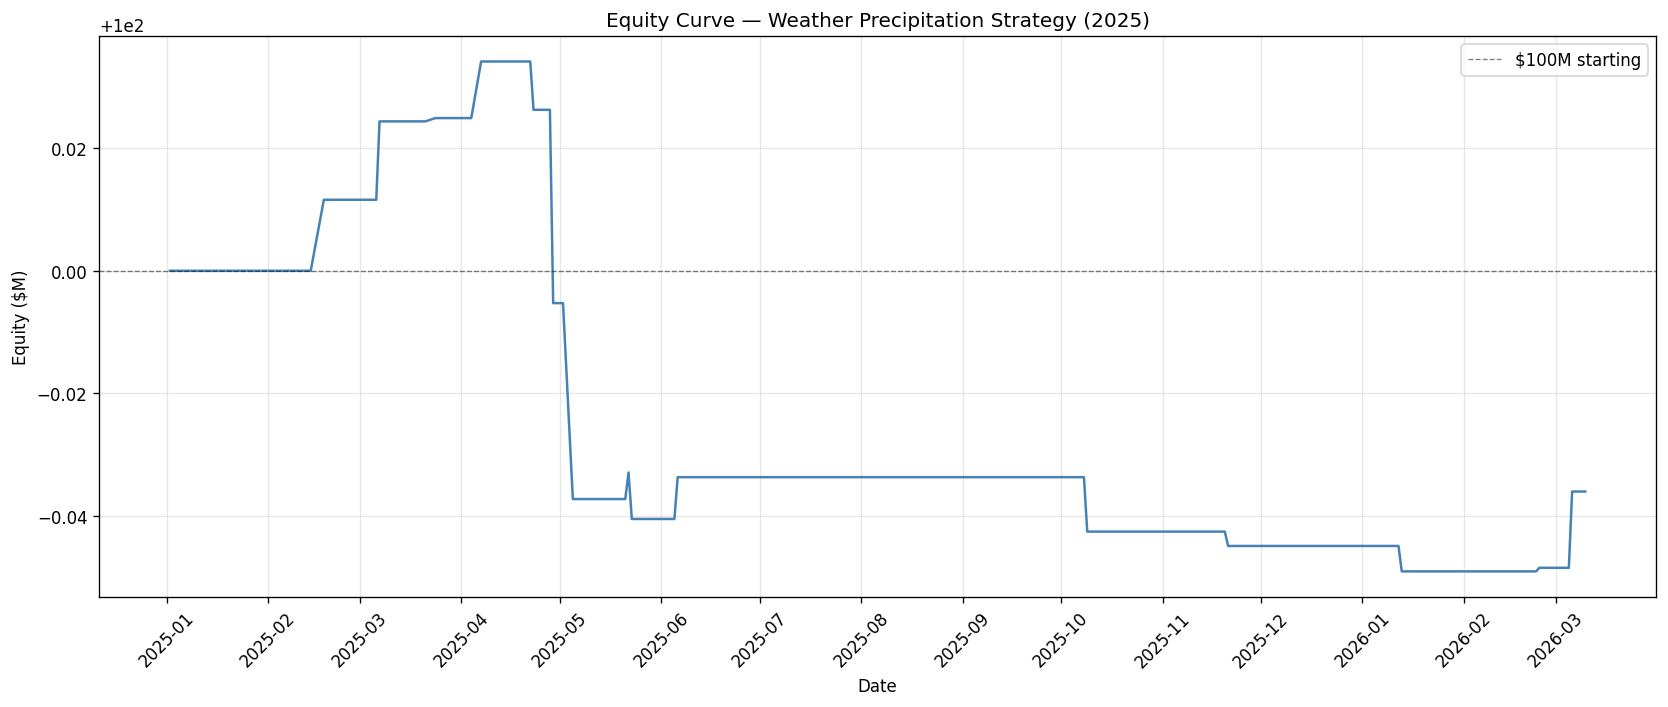

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(result_df.index, result_df["equity"] / 1e6, linewidth=1.5, color="steelblue")
ax.axhline(100, color="black", linewidth=0.8, linestyle="--", alpha=0.5, label="$100M starting")
ax.set_title("Equity Curve — Weather Precipitation Strategy (2025)")
ax.set_ylabel("Equity ($M)")
ax.set_xlabel("Date")
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
fig.savefig(VISUALS_DIR / "weather_equity_curve.png", bbox_inches="tight", facecolor="white")
plt.show()

## Price + Signal Overlay

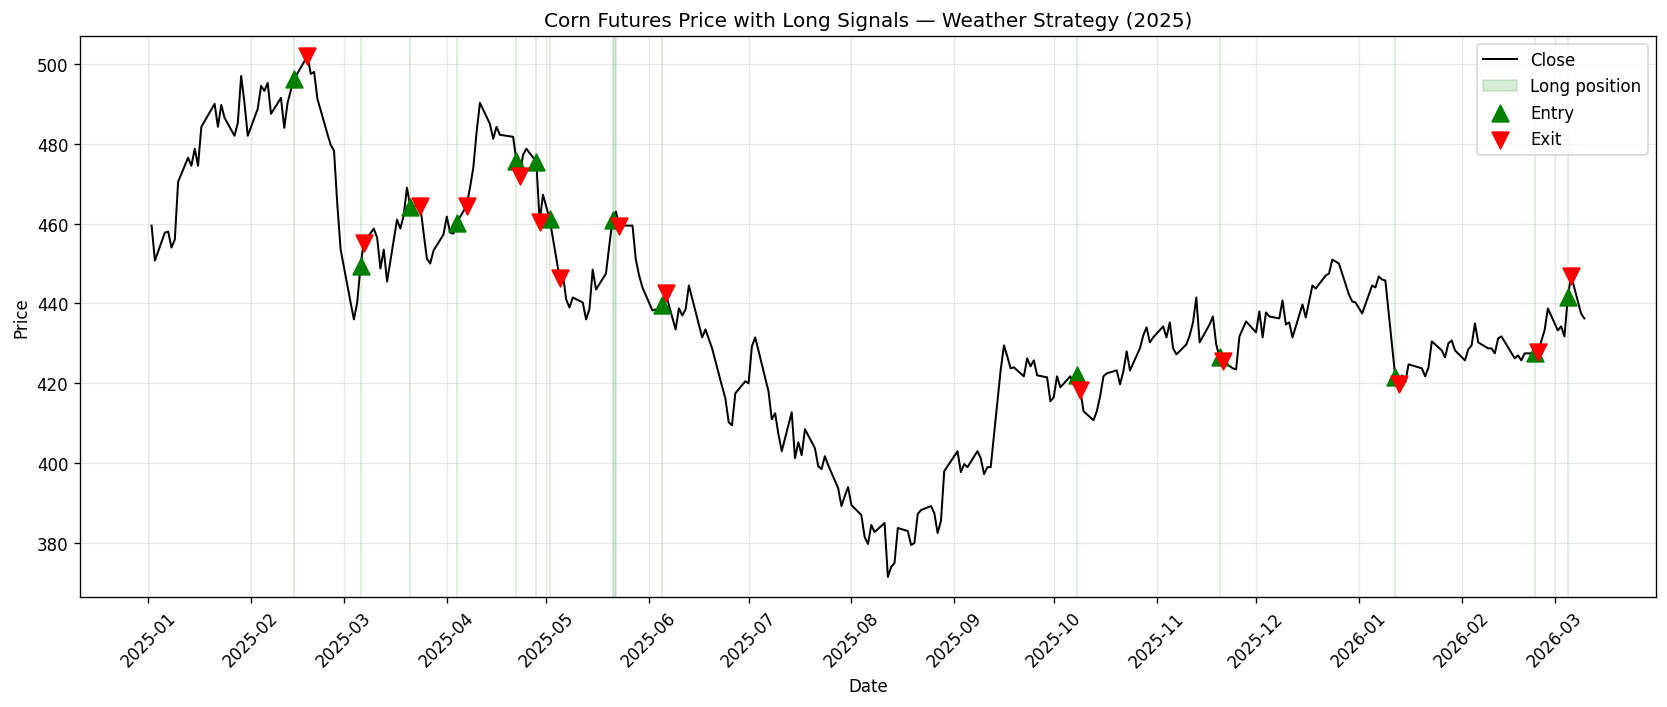

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(result_df.index, result_df["Close"], linewidth=1.2, color="black", label="Close")

# Shade long position regions
long_pos = result_df["position"] == 1
ymin, ymax = result_df["Close"].min() - 5, result_df["Close"].max() + 5
ax.fill_between(
    result_df.index, ymin, ymax, where=long_pos,
    alpha=0.15, color="green", label="Long position",
)

# Mark entry/exit points from trade log
if len(trade_log) > 0:
    ax.scatter(trade_log["entry_date"], trade_log["entry_price"],
               marker="^", color="green", s=100, zorder=5, label="Entry")
    ax.scatter(trade_log["exit_date"], trade_log["exit_price"],
               marker="v", color="red", s=100, zorder=5, label="Exit")

ax.set_ylim(ymin, ymax)
ax.set_title("Corn Futures Price with Long Signals — Weather Strategy (2025)")
ax.set_ylabel("Price")
ax.set_xlabel("Date")
ax.legend(loc="upper right")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
fig.savefig(VISUALS_DIR / "weather_price_signals.png", bbox_inches="tight", facecolor="white")
plt.show()

## Drawdown from Peak Equity

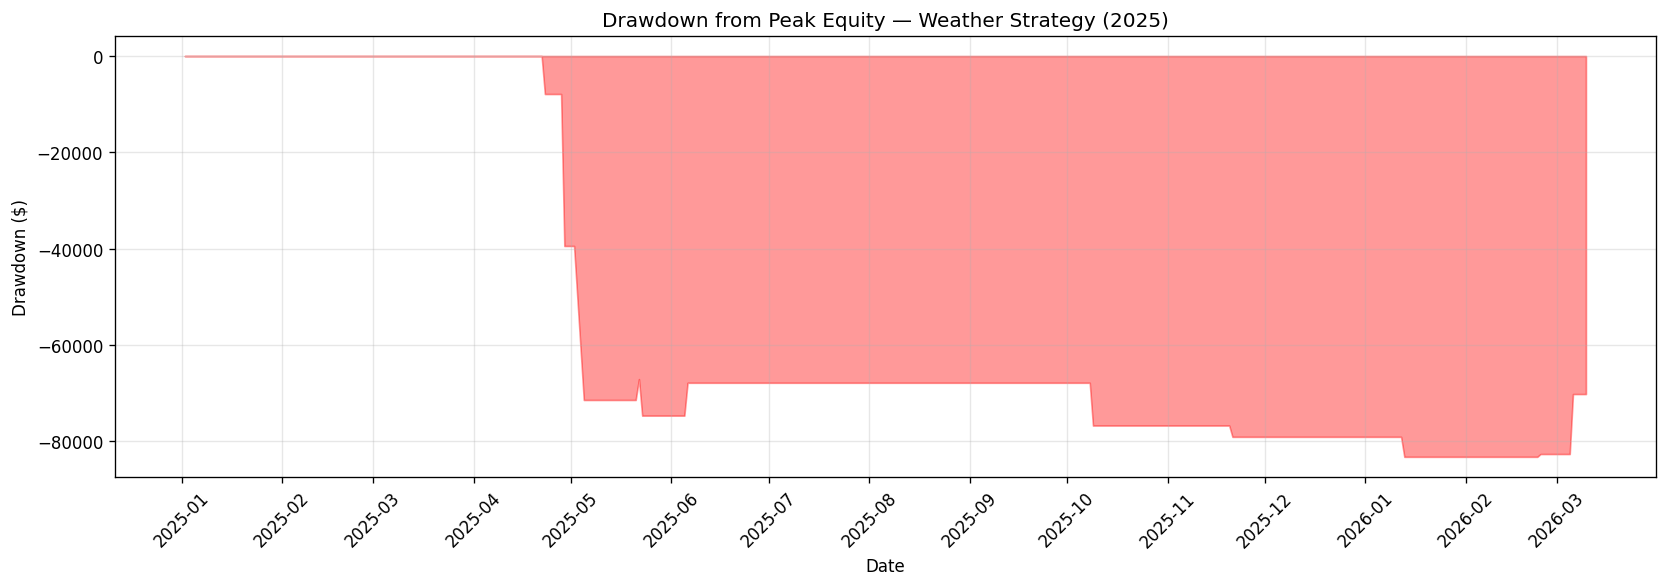

In [8]:
equity = result_df["equity"]
running_max = equity.cummax()
drawdown = equity - running_max

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(result_df.index, drawdown, 0, color="red", alpha=0.4)
ax.set_title("Drawdown from Peak Equity — Weather Strategy (2025)")
ax.set_ylabel("Drawdown ($)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
fig.savefig(VISUALS_DIR / "weather_drawdown.png", bbox_inches="tight", facecolor="white")
plt.show()